# Assignment 1 - Optional part

## Part 1 - Improve the performance
In this section, we explore some techniques with the aim to maximize the performance of the 1-layer FCNN.
### Baseline
The baseline for this section will be the best performing model from the mandatory part, which has parameters
- batch_size = 100
- num_of_epochs = 40
- learning_rate = 0.001
- regularization_parameter = 0.1
and achieved test accuracy of **0.392**.

### a) using all available data for training

In [11]:
# Load all data batches
from utils import load_batch
import matplotlib.pyplot as plt
import numpy as np

X, Y, y = load_batch("data_batch_1")
print("Shape for data batch 1:")
print(X.shape, Y.shape, y.shape)
for i in range(2,6):
    X_temp, Y_temp, y_temp = load_batch(f"data_batch_{i}")
    X = np.concatenate((X, X_temp), axis=1)
    Y = np.concatenate((Y, Y_temp), axis=1)
    y = np.concatenate((y, y_temp))
print("Shape for combined data:")
print(X.shape, Y.shape, y.shape)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


Shape for data batch 1:
(3072, 10000) (10, 10000) (10000,)
Shape for combined data:
(3072, 50000) (10, 50000) (50000,)


In [25]:
# split into training and validation sets
split = int(0.95 * X.shape[1])
X_train, Y_train, y_train = X[:, :split], Y[:, :split], y[:split]
X_val, Y_val, y_val = X[:, split:], Y[:, split:], y[split:]
print("Shape for training set:")
print(X_train.shape, Y_train.shape, y_train.shape)
print("Shape for validation set:")
print(X_val.shape, Y_val.shape, y_val.shape)

Shape for training set:
(3072, 47500) (10, 47500) (47500,)
Shape for validation set:
(3072, 2500) (10, 2500) (2500,)


In [ ]:
# train with the default parameters
from model import Model
from optimizer import Optimizer
from nodes import CrossEntropyLoss
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.0)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=100, batch_size=100, print_every=10)

Epoch 10/60 - Train Loss: 1.8611, Val Loss: 1.8805, Train Acc: 0.3625, Val Acc: 0.3512
Epoch 20/60 - Train Loss: 1.8110, Val Loss: 1.8357, Train Acc: 0.3798, Val Acc: 0.3656
Epoch 30/60 - Train Loss: 1.7854, Val Loss: 1.8171, Train Acc: 0.3887, Val Acc: 0.3692
Epoch 40/60 - Train Loss: 1.7700, Val Loss: 1.8088, Train Acc: 0.3947, Val Acc: 0.3724
Epoch 50/60 - Train Loss: 1.7571, Val Loss: 1.7961, Train Acc: 0.3993, Val Acc: 0.3776
Epoch 60/60 - Train Loss: 1.7471, Val Loss: 1.7887, Train Acc: 0.4024, Val Acc: 0.3888


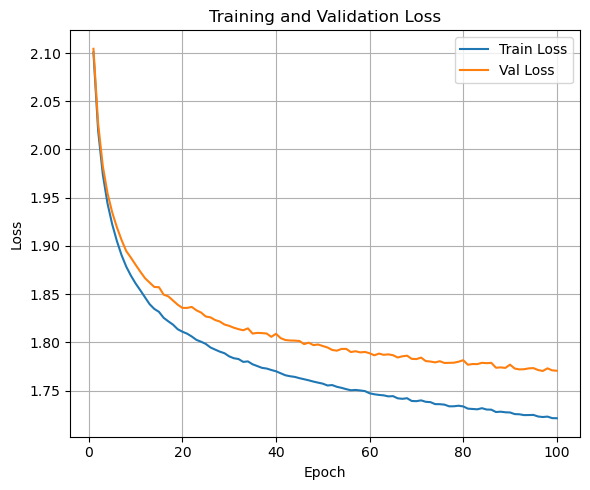

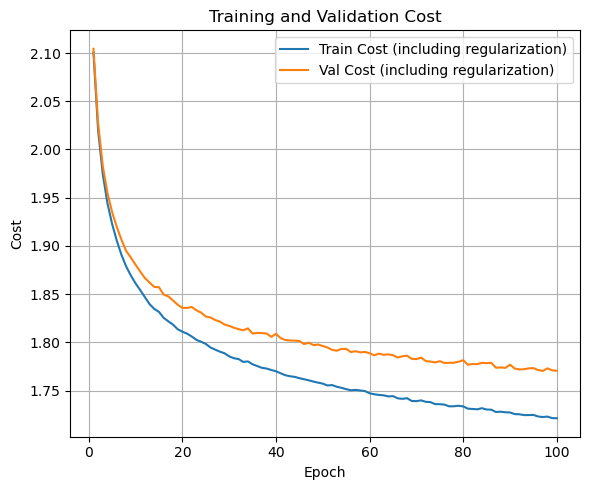

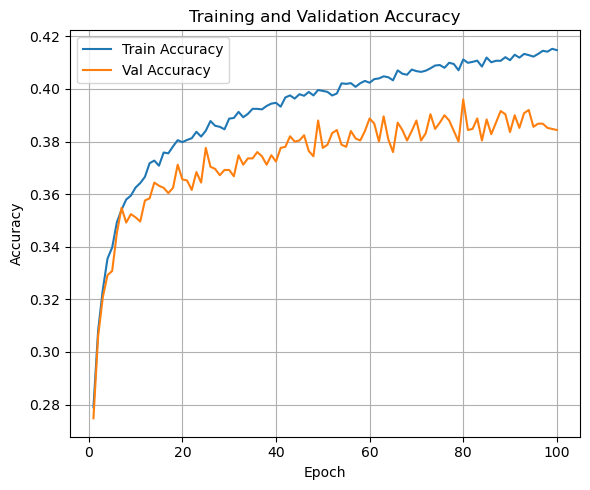

In [36]:
optimizer.plot_training_progress()

In [37]:
# test the model on the test set
X_test, Y_test, y_test = load_batch("test_batch")
print("test accuracy: ", optimizer.compute_accuracy(X_test, y_test))

test accuracy:  0.4026


### Augmenting data by flipping images horizontally

In [44]:
xx = X_test[:,0]
aa = np.int32(np.arange(32)).reshape((32, 1))
bb = np.int32(np.arange(31, -1, -1)).reshape((32, 1))
vv = np.tile(32*aa, (1, 32))
ind_flip = vv.reshape((32*32, 1)) + np.tile(bb, (32, 1))
inds_flip = np.vstack((ind_flip, 1024+ind_flip))
inds_flip = np.vstack((inds_flip, 2048+ind_flip))
xx_flipped = xx[inds_flip]

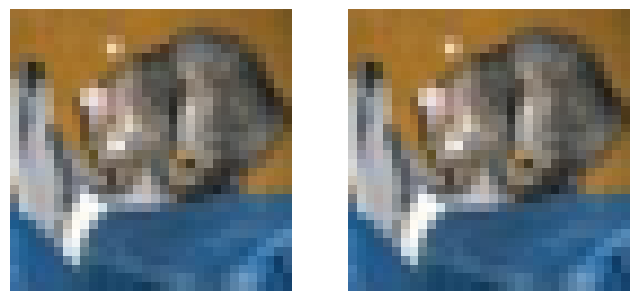

In [46]:
ni = 5
fig, axs = plt.subplots(1, 2, figsize=(8, 5))
xx = xx.reshape((32, 32, 3), order='F')
xx = np.transpose(xx, (1, 0, 2))
axs[0].imshow(xx)
axs[0].axis('off')
xx_flipped = xx_flipped.reshape((32, 32, 3), order='F')
xx_flipped = np.transpose(xx_flipped, (1, 0, 2))
axs[1].imshow(xx)
axs[1].axis('off')
plt.pause(0.1)